### KNN

**K-ближайших соседей (KNN)** - это алгоритм классификации, который принимает решение на основе "мнения большинства соседей". Принцип работы: чтобы классифицировать новый объект, алгоритм находит K самых ближайших объектов из обучающей выборки и определяет класс по большинству голосов среди них.

## Используемые библиотеки

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA

## Используемый датасет

In [17]:
wine = load_wine()

features = [
    ("Alcohol", "Содержание алкоголя", "% (об.)"),
    ("Malic acid", "Яблочная кислота", "г/л"),
    ("Ash", "Зольность (минералы)", "г/л"),
    ("Alcalinity of ash", "Щелочность золы", "усл. ед."),
    ("Magnesium", "Магний", "мг/л"),
    ("Total phenols", "Общие фенолы", "мг/л"),
    ("Flavanoids", "Флавоноиды (цвет)", "мг/л"),
    ("Nonflavanoid phenols", "Нефлавоноидные фенолы", "мг/л"),
    ("Proanthocyanins", "Проантоцианидины (терпкость)", "мг/л"),
    ("Color intensity", "Интенсивность цвета", "опт. плотность"),
    ("Hue", "Оттенок цвета", "отношение"),
    ("OD280/OD315", "Оптическая плотность (белки)", "отношение"),
    ("Proline", "Пролин", "мг/л")
]
print()

for i, (name, desc, unit) in enumerate(features, 1):
    print(f"{i:2}. {name:20} - {desc:30} [{unit}]")

df = pd.DataFrame(data=wine.data, columns=wine.feature_names)
df['target'] = wine.target
df['wine_class'] = df['target'].apply(lambda x: wine.target_names[x])

print("Размер датасета:", df.shape)
print("\nНазвания классов:", wine.target_names)
print("\nПервые 5 строк:")
print(df.head())

print("\nСтатистика по признакам:")
print(df.describe())


 1. Alcohol              - Содержание алкоголя            [% (об.)]
 2. Malic acid           - Яблочная кислота               [г/л]
 3. Ash                  - Зольность (минералы)           [г/л]
 4. Alcalinity of ash    - Щелочность золы                [усл. ед.]
 5. Magnesium            - Магний                         [мг/л]
 6. Total phenols        - Общие фенолы                   [мг/л]
 7. Flavanoids           - Флавоноиды (цвет)              [мг/л]
 8. Nonflavanoid phenols - Нефлавоноидные фенолы          [мг/л]
 9. Proanthocyanins      - Проантоцианидины (терпкость)   [мг/л]
10. Color intensity      - Интенсивность цвета            [опт. плотность]
11. Hue                  - Оттенок цвета                  [отношение]
12. OD280/OD315          - Оптическая плотность (белки)   [отношение]
13. Proline              - Пролин                         [мг/л]
Размер датасета: (178, 15)

Названия классов: ['class_0' 'class_1' 'class_2']

Первые 5 строк:
   alcohol  malic_acid   ash  alca

## Обработка датасета

In [18]:
print("Пропуски в данных:")
print(df.isnull().sum())

X = wine.data
y = wine.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print(f"\nОбучающая выборка: {X_train.shape[0]} образцов")
print(f"Тестовая выборка: {X_test.shape[0]} образцов")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Пропуски в данных:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
wine_class                      0
dtype: int64

Обучающая выборка: 124 образцов
Тестовая выборка: 54 образцов


## Тепловая карта

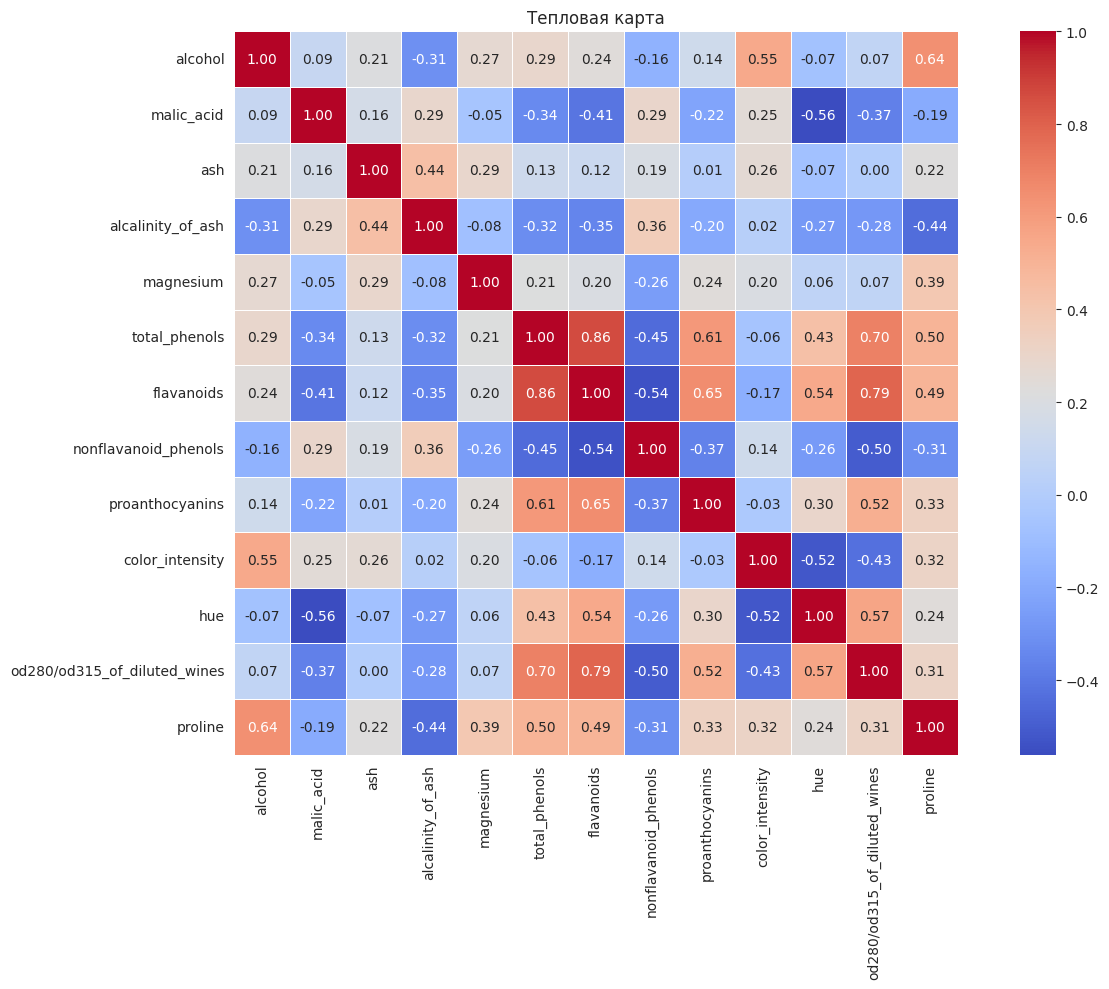

In [19]:
corr_matrix = df[wine.feature_names].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            square=True,
            fmt='.2f',
            linewidths=0.5)
plt.title('Тепловая карта')
plt.tight_layout()
plt.show()

## Обучение модели

In [20]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

print(f"Модель KNN с K={knn.n_neighbors}")
print(f"Метрика расстояния: {knn.metric}")

Модель KNN с K=5
Метрика расстояния: minkowski


## Прогнозы модели

In [21]:
y_pred = knn.predict(X_test_scaled)

y_pred_proba = knn.predict_proba(X_test_scaled)

print("Сравнение первых 10 реальных значений и предсказаний:")
for i in range(10):
    print(f"Реальный: {wine.target_names[y_test[i]]:12} | "
          f"Предсказанный: {wine.target_names[y_pred[i]]:12}")

print(f"\nВероятности для первых 5 образцов:")
for i in range(5):
    proba = np.round(y_pred_proba[i], 3)
    print(f"Образец {i+1}: class_0={proba[0]}, class_1={proba[1]}, class_2={proba[2]} -> предсказан {wine.target_names[y_pred[i]]}")

Сравнение первых 10 реальных значений и предсказаний:
Реальный: class_0      | Предсказанный: class_0     
Реальный: class_1      | Предсказанный: class_1     
Реальный: class_0      | Предсказанный: class_0     
Реальный: class_0      | Предсказанный: class_0     
Реальный: class_0      | Предсказанный: class_0     
Реальный: class_0      | Предсказанный: class_0     
Реальный: class_2      | Предсказанный: class_2     
Реальный: class_1      | Предсказанный: class_1     
Реальный: class_1      | Предсказанный: class_1     
Реальный: class_2      | Предсказанный: class_2     

Вероятности для первых 5 образцов:
Образец 1: class_0=1.0, class_1=0.0, class_2=0.0 -> предсказан class_0
Образец 2: class_0=0.0, class_1=1.0, class_2=0.0 -> предсказан class_1
Образец 3: class_0=1.0, class_1=0.0, class_2=0.0 -> предсказан class_0
Образец 4: class_0=1.0, class_1=0.0, class_2=0.0 -> предсказан class_0
Образец 5: class_0=0.8, class_1=0.2, class_2=0.0 -> предсказан class_0


## Графики выходных результатов

Точность модели KNN: 0.944

Отчет по классификации:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        18
     class_1       1.00      0.86      0.92        21
     class_2       0.83      1.00      0.91        15

    accuracy                           0.94        54
   macro avg       0.94      0.95      0.94        54
weighted avg       0.95      0.94      0.94        54



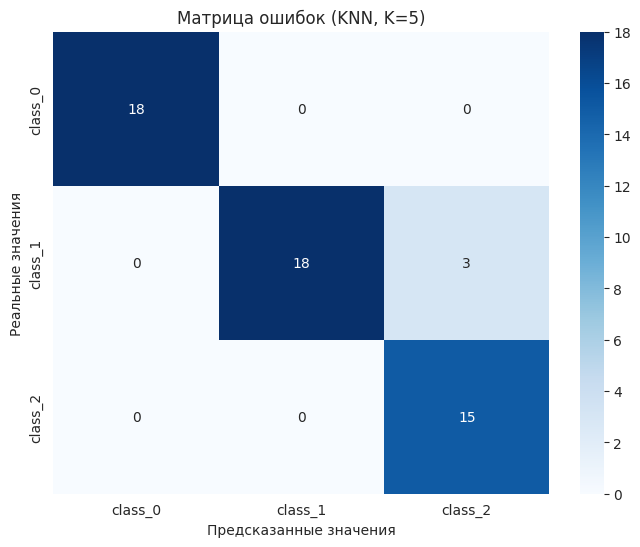

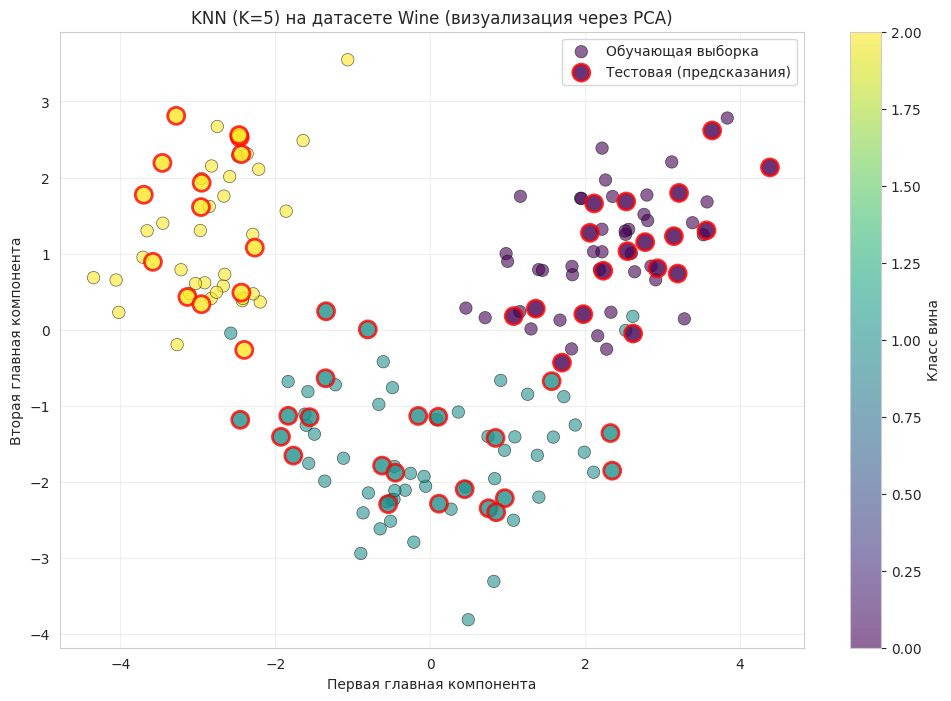


Подбор оптимального K:


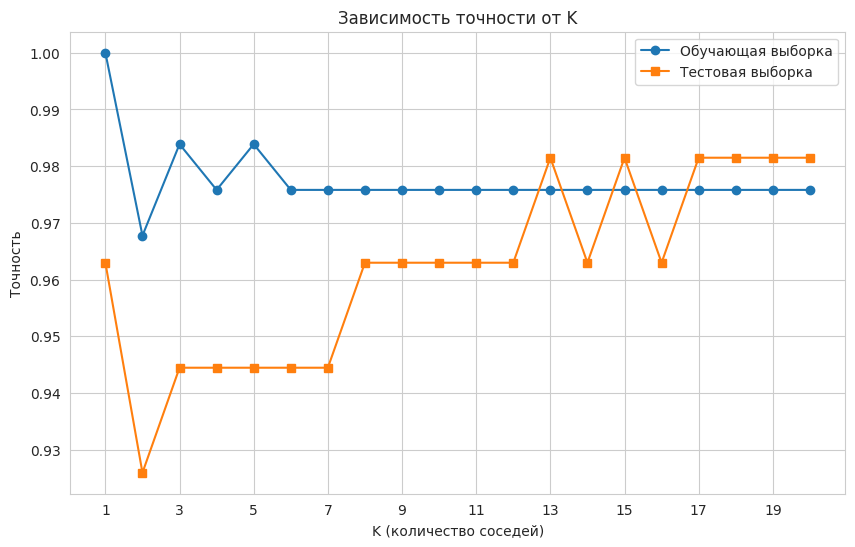

Оптимальное K: 13 с точностью 0.981


In [22]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Точность модели KNN: {accuracy:.3f}")

print("\nОтчет по классификации:")
print(classification_report(y_test, y_pred, target_names=wine.target_names))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm,
            annot=True,
            cmap='Blues',
            fmt='d',
            xticklabels=wine.target_names,
            yticklabels=wine.target_names)
plt.title(f'Матрица ошибок')
plt.ylabel('Реальные значения')
plt.xlabel('Предсказанные значения')
plt.show()

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

knn_pca = KNeighborsClassifier(n_neighbors=5)
knn_pca.fit(X_train_pca, y_train)
y_pred_pca = knn_pca.predict(X_test_pca)

plt.figure(figsize=(12, 8))
scatter_train = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1],
                            c=y_train, cmap='viridis', alpha=0.6,
                            s=80, edgecolors='k', linewidth=0.5)
scatter_test = plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1],
                           c=y_pred_pca, cmap='viridis',
                           s=150, edgecolors='red', linewidth=2,
                           marker='o', alpha=0.8)

plt.title(f'Визуализация через PCA)')
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.colorbar(scatter_train, label='Класс вина')
plt.legend(['Обучающая выборка', 'Тестовая'], loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()


print("\nПодбор оптимального K:")
k_values = range(1, 21)
train_scores = []
test_scores = []

for k in k_values:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train_scaled, y_train)
    train_scores.append(knn_k.score(X_train_scaled, y_train))
    test_scores.append(knn_k.score(X_test_scaled, y_test))

plt.figure(figsize=(10, 6))
plt.plot(k_values, train_scores, 'o-', label='Обучающая выборка')
plt.plot(k_values, test_scores, 's-', label='Тестовая выборка')
plt.xlabel('K')
plt.ylabel('Точность')
plt.title('Зависимость точности от K')
plt.legend()
plt.grid(True)
plt.xticks(k_values[::2])
plt.show()

best_k = k_values[test_scores.index(max(test_scores))]
print(f"Оптимальное K: {best_k} с точностью {max(test_scores):.3f}")